In [14]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
BASE_PATH = "/content/drive/MyDrive/Delhivery_Graph_ETA"

feature_store = pd.read_csv(
    f"{BASE_PATH}/data/feature_store/feature_store.csv"
)

graph_features = pd.read_csv(
    f"{BASE_PATH}/data/graph_data/graph_ml_feature_store.csv"
)

print(feature_store.shape)
print(graph_features.shape)


(144867, 35)
(1657, 43)


In [4]:
src_graph = graph_features.add_prefix("src_")

src_graph = src_graph.rename(
    columns={"src_facility":"source_center"}
)

In [5]:
dst_graph = graph_features.add_prefix("dst_")

dst_graph = dst_graph.rename(
    columns={"dst_facility":"destination_center"}
)

In [6]:
df = feature_store.copy()

df = df.merge(
    src_graph,
    on="source_center",
    how="left"
)

df = df.merge(
    dst_graph,
    on="destination_center",
    how="left"
)

print(df.shape)

In [17]:
drop_cols = [

    "actual_time",
    "segment_actual_time",
    "od_end_time",

    "segment_factor",

    # Unknown provenance
    "cutoff_factor"
]

df = df.drop(
    columns=drop_cols,
    errors="ignore"
)

In [18]:
TARGET = "factor"

assert TARGET in df.columns

In [19]:
[c for c in df.columns if "factor" in c.lower()]

['factor']

Split data

In [20]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(
        df,
        groups=df["trip_uuid"]
    )
)

In [21]:
train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(train_df.shape)
print(test_df.shape)

(116451, 114)
(28416, 114)


In [22]:
overlap = set(train_df.trip_uuid).intersection(
    set(test_df.trip_uuid)
)

print(len(overlap))

0


Baseline feat

In [23]:
baseline_features = [

    "route_type",

    "osrm_time",
    "osrm_distance",
    "osrm_speed",

    "trip_hour",
    "trip_weekday",
    "trip_month",
    "is_weekend",

    "trip_to_scan_minutes",
    "trip_to_cutoff_minutes",

    "source_volume",
    "destination_volume",
    "corridor_volume"
]

In [ ]:
Graph feat

In [24]:
centrality_features = [

    "src_degree_centrality",
    "src_in_degree_centrality",
    "src_out_degree_centrality",
    "src_betweenness_centrality",
    "src_closeness_centrality",
    "src_pagerank",
    "src_hub_score",
    "src_authority_score",

    "dst_degree_centrality",
    "dst_in_degree_centrality",
    "dst_out_degree_centrality",
    "dst_betweenness_centrality",
    "dst_closeness_centrality",
    "dst_pagerank",
    "dst_hub_score",
    "dst_authority_score"
]

Communities

In [26]:
community_features = [

    "src_community_id",
    "src_community_size",

    "dst_community_id",
    "dst_community_size"
]

Embeddings

In [27]:
embedding_features = [

    col for col in df.columns
    if "embedding_" in col
]

Graph Feature Set

In [28]:
graph_features_all = (

    baseline_features
    + centrality_features
    + community_features
    + embedding_features
)

_______________________________________________________________________________________

In [29]:
X_train_base = train_df[baseline_features]
X_test_base = test_df[baseline_features]

In [30]:
X_train_graph = train_df[graph_features_all]
X_test_graph = test_df[graph_features_all]

In [31]:
y_train = train_df[TARGET]
y_test = test_df[TARGET]

Eval fxn

In [32]:
def evaluate(y_true, pred):

    mae = mean_absolute_error(
        y_true,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            pred
        )
    )

    r2 = r2_score(
        y_true,
        pred
    )

    mape = (
        np.abs(
            (y_true - pred) / y_true
        )
    ).mean() * 100

    return {

        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape
    }

Mean baseline

In [33]:
mean_pred = np.repeat(
    y_train.mean(),
    len(y_test)
)

mean_results = evaluate(
    y_test,
    mean_pred
)

mean_results

{'MAE': 0.6235200067622484,
 'RMSE': np.float64(1.5546249971470538),
 'R2': -0.00022699542812776308,
 'MAPE': np.float64(29.746670442201616)}

Baseline RF Model

In [34]:
cat_base = ["route_type"]

num_base = list(
    set(baseline_features)
    - set(cat_base)
)

In [35]:
#PIPELINE
base_prep = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        cat_base
    ),

    (
        "num",
        SimpleImputer(
            strategy="median"
        ),
        num_base
    )
])

In [36]:
#MODEL
baseline_model = Pipeline([

    ("prep", base_prep),

    (
        "rf",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [37]:
#TRAIN
baseline_model.fit(
    X_train_base,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_type']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['source_volume',
                                                   'trip_to_cutoff_minutes',
                                                   'trip_hour', 'is_weekend',
                                                   'trip_to_scan_minutes',
                                                   'corridor_volume',
                                                   'osrm_time', 'trip_month',
                                                   'trip_weekday',
                                                   'destination_volume',
                                                   'osrm_speed',
                                                   'osrm_distance'])])),
                ('rf',
                 RandomForestRegressor(max_depth=15, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [38]:
#PREDICT
baseline_pred = baseline_model.predict(
    X_test_base
)

baseline_results = evaluate(
    y_test,
    baseline_pred
)

baseline_results

{'MAE': 0.4177613180772168,
 'RMSE': np.float64(0.9823482261376131),
 'R2': 0.600627451981135,
 'MAPE': np.float64(19.277873347201247)}

Graph RF Model

In [39]:
graph_cats = [

    "route_type",

    "src_community_id",
    "dst_community_id"
]

In [40]:
graph_nums = list(
    set(graph_features_all)
    - set(graph_cats)
)

In [41]:
graph_prep = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        graph_cats
    ),

    (
        "num",
        SimpleImputer(
            strategy="median"
        ),
        graph_nums
    )
])

In [42]:
#Model
graph_model = Pipeline([

    ("prep", graph_prep),

    (
        "rf",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [43]:
graph_model.fit(
    X_train_graph,
    y_train
)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_type',
                                                   'src_community_id',
                                                   'dst_community_id']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['src_embedding_2',
                                                   'src_embedding_17',
                                                   'dst_closeness_centrality',
                                                   'src_authority_score',
                                                   'dst_out_degree_centrality',
                                                   'dst_embedding_4',
                                                   'dst_embedding_13',
                                                   's...
                                                   'src_pagerank',
                                                   'dst_authority_score',
                                                   'src_embedding_29',
                                                   'dst_embedding_15',
                                                   'dst_embedding_7',
                                                   'dst_embedding_11',
                                                   'corridor_volume',
                                                   'dst_pagerank',
                                                   'dst_embedding_3',
                                                   'src_embedding_8',
                                                   'dst_embedding_8',
                                                   'src_embedding_1',
                                                   'osrm_speed',
                                                   'dst_embedding_27',
                                                   'dst_embedding_1', ...])])),
                ('rf',
                 RandomForestRegressor(max_depth=15, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [44]:
graph_pred = graph_model.predict(
    X_test_graph
)

graph_results = evaluate(
    y_test,
    graph_pred
)

graph_results

{'MAE': 0.41292155246391693,
 'RMSE': np.float64(0.9370193039120974),
 'R2': 0.6366339442925203,
 'MAPE': np.float64(19.486512233748847)}

comparison table

In [45]:
results = pd.DataFrame({

    "Mean": mean_results,
    "Baseline": baseline_results,
    "Graph": graph_results

}).T

results

,MAE,RMSE,R2,MAPE
Mean,0.623520,1.554625,-0.000227,29.746670
Baseline,0.417761,0.982348,0.600627,19.277873
Graph,0.412922,0.937019,0.636634,19.486512


uplift

In [46]:
mae_gain = (

    baseline_results["MAE"]
    - graph_results["MAE"]

) / baseline_results["MAE"] * 100

rmse_gain = (

    baseline_results["RMSE"]
    - graph_results["RMSE"]

) / baseline_results["RMSE"] * 100

print(f"MAE Improvement: {mae_gain:.2f}%")
print(f"RMSE Improvement: {rmse_gain:.2f}%")

MAE Improvement: 1.16%
RMSE Improvement: 4.61%


feat importance

In [47]:
rf = graph_model.named_steps["rf"]

importances = rf.feature_importances_

feature_names = graph_model.named_steps[
    "prep"
].get_feature_names_out()

importance_df = pd.DataFrame({

    "feature": feature_names,
    "importance": importances

})

importance_df = importance_df.sort_values(
    "importance",
    ascending=False
)

importance_df.head(30)

,feature,importance
230,num__trip_to_cutoff_minutes,0.133870
249,num__osrm_distance,0.091505
253,num__src_embedding_12,0.063183
199,num__osrm_time,0.051421
215,num__osrm_speed,0.047516
223,num__src_embedding_26,0.036964
232,num__trip_hour,0.030800
247,num__dst_embedding_28,0.029453
225,num__dst_embedding_21,0.028687
196,num__trip_weekday,0.028303


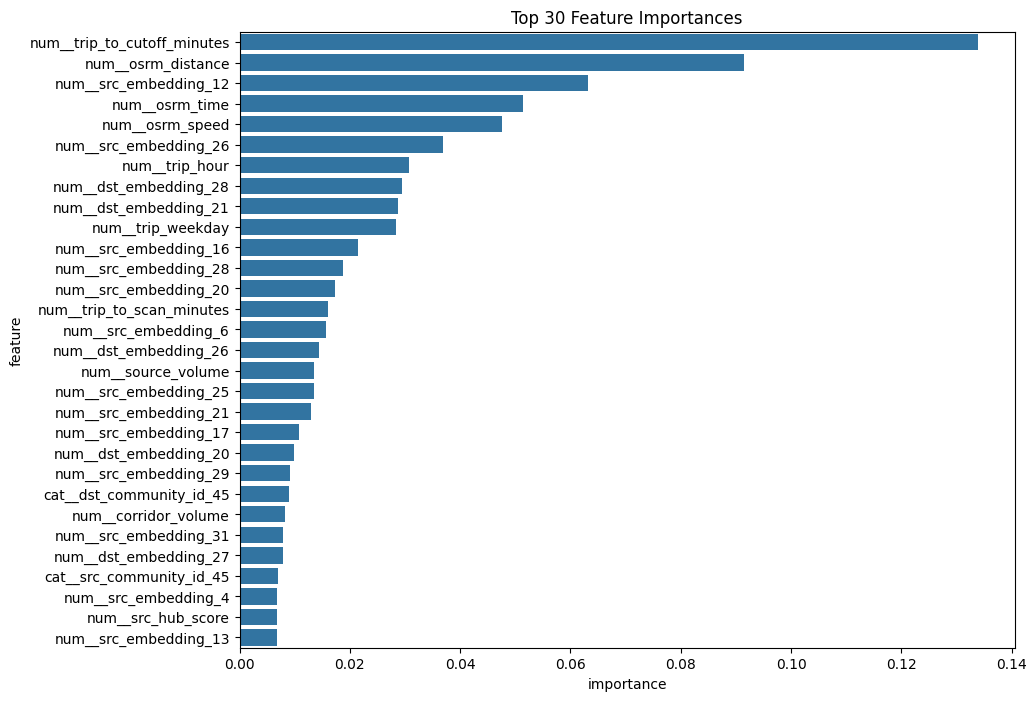

In [48]:
#PLOT
top30 = importance_df.head(30)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top30,
    x="importance",
    y="feature"
)

plt.title(
    "Top 30 Feature Importances"
)

plt.show()

More models to be added

In [49]:
!pip install lightgbm -q

In [50]:
from lightgbm import LGBMRegressor

LightGBM baseline model

In [51]:
lgbm_base = Pipeline([

    ("prep", base_prep),

    (
        "lgbm",
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [52]:
lgbm_base.fit(
    X_train_base,
    y_train
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007327 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1997
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 14
[LightGBM] [Info] Start training from score 2.124701


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_type']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['source_volume',
                                                   'trip_to_cutoff_minutes',
                                                   'trip_hour', 'is_weekend',
                                                   'trip_to_scan_minutes',
                                                   'corridor_volume',
                                                   'osrm_time', 'trip_month',
                                                   'trip_weekday',
                                                   'destination_volume',
                                                   'osrm_speed',
                                                   'osrm_distance'])])),
                ('lgbm',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               n_estimators=1000, n_jobs=-1, random_state=42,
                               subsample=0.8))])

In [54]:
lgbm_base_pred = lgbm_base.predict(
    X_test_base
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [55]:
lgbm_base_results = evaluate(
    y_test,
    lgbm_base_pred
)

lgbm_base_results

{'MAE': 0.44458589525180975,
 'RMSE': np.float64(1.0104922669996388),
 'R2': 0.5774157882418608,
 'MAPE': np.float64(20.672455592686802)}

Lightgbm graph

In [56]:
lgbm_graph = Pipeline([

    ("prep", graph_prep),

    (
        "lgbm",
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [57]:
lgbm_graph.fit(
    X_train_graph,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.128192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21021
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 238
[LightGBM] [Info] Start training from score 2.124701


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_type',
                                                   'src_community_id',
                                                   'dst_community_id']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['src_embedding_2',
                                                   'src_embedding_17',
                                                   'dst_closeness_centrality',
                                                   'src_authority_score',
                                                   'dst_out_degree_centrality',
                                                   'dst_embedding_4',
                                                   'dst_embedding_13',
                                                   's...
                                                   'src_embedding_29',
                                                   'dst_embedding_15',
                                                   'dst_embedding_7',
                                                   'dst_embedding_11',
                                                   'corridor_volume',
                                                   'dst_pagerank',
                                                   'dst_embedding_3',
                                                   'src_embedding_8',
                                                   'dst_embedding_8',
                                                   'src_embedding_1',
                                                   'osrm_speed',
                                                   'dst_embedding_27',
                                                   'dst_embedding_1', ...])])),
                ('lgbm',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               n_estimators=1000, n_jobs=-1, random_state=42,
                               subsample=0.8))])

In [59]:
lgbm_graph_pred = lgbm_graph.predict(
    X_test_graph
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [60]:
lgbm_graph_results = evaluate(
    y_test,
    lgbm_graph_pred
)

lgbm_graph_results

{'MAE': 0.40625107629276497,
 'RMSE': np.float64(0.9319924753432858),
 'R2': 0.6405221872289226,
 'MAPE': np.float64(18.743205115259062)}

In [61]:
comparison = pd.DataFrame({

    "Mean": mean_results,

    "RF_Baseline": baseline_results,
    "RF_Graph": graph_results,

    "LGBM_Baseline": lgbm_base_results,
    "LGBM_Graph": lgbm_graph_results

}).T

comparison

,MAE,RMSE,R2,MAPE
Mean,0.623520,1.554625,-0.000227,29.746670
RF_Baseline,0.417761,0.982348,0.600627,19.277873
RF_Graph,0.412922,0.937019,0.636634,19.486512
LGBM_Baseline,0.444586,1.010492,0.577416,20.672456
LGBM_Graph,0.406251,0.931992,0.640522,18.743205


In [62]:
mae_gain_lgbm = (

    lgbm_base_results["MAE"]
    - lgbm_graph_results["MAE"]

) / lgbm_base_results["MAE"] * 100


rmse_gain_lgbm = (

    lgbm_base_results["RMSE"]
    - lgbm_graph_results["RMSE"]

) / lgbm_base_results["RMSE"] * 100


r2_gain_lgbm = (

    lgbm_graph_results["R2"]
    - lgbm_base_results["R2"]

)

print(f"LightGBM MAE Improvement : {mae_gain_lgbm:.2f}%")
print(f"LightGBM RMSE Improvement: {rmse_gain_lgbm:.2f}%")
print(f"LightGBM R² Improvement  : {r2_gain_lgbm:.4f}")

LightGBM MAE Improvement : 8.62%
LightGBM RMSE Improvement: 7.77%
LightGBM R² Improvement  : 0.0631


In [63]:
lgbm = lgbm_graph.named_steps["lgbm"]

In [64]:
feature_names = (
    lgbm_graph.named_steps["prep"]
    .get_feature_names_out()
)

importance_df_lgbm = pd.DataFrame({

    "feature": feature_names,

    "importance": lgbm.feature_importances_

})

importance_df_lgbm = importance_df_lgbm.sort_values(
    "importance",
    ascending=False
)

importance_df_lgbm.head(30)

,feature,importance
230,num__trip_to_cutoff_minutes,2684
249,num__osrm_distance,1533
215,num__osrm_speed,1333
199,num__osrm_time,1329
232,num__trip_hour,1302
234,num__trip_to_scan_minutes,979
196,num__trip_weekday,830
209,num__corridor_volume,705
223,num__src_embedding_26,443
195,num__src_embedding_4,421


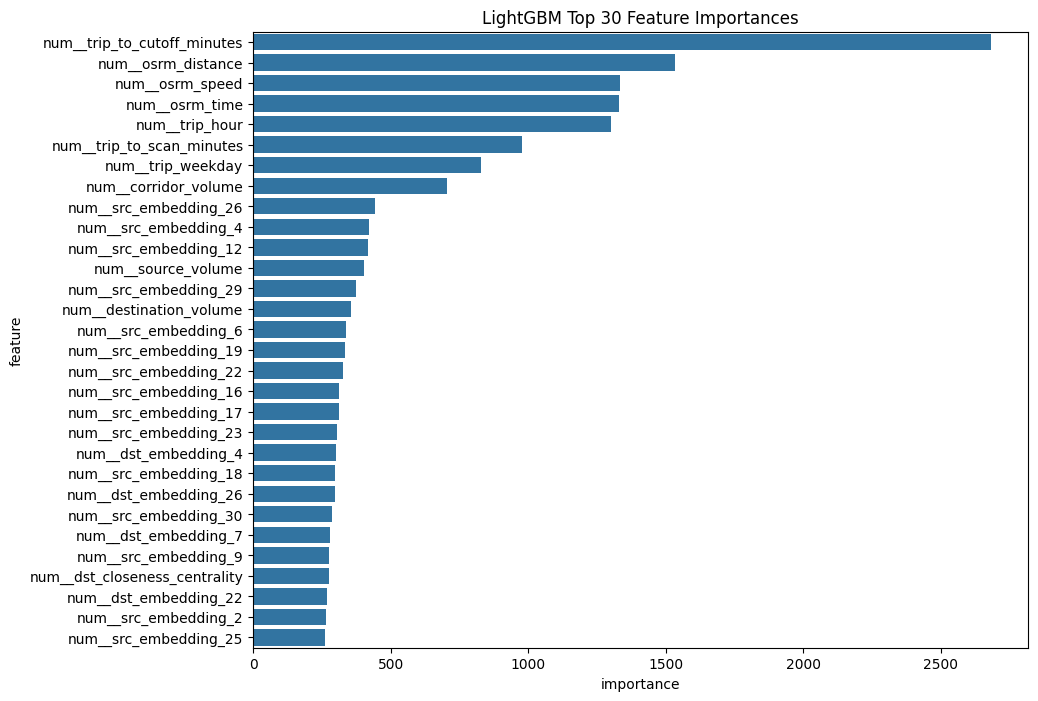

In [65]:
top30 = importance_df_lgbm.head(30)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top30,
    x="importance",
    y="feature"
)

plt.title(
    "LightGBM Top 30 Feature Importances"
)

plt.show()

In [66]:
print("="*60)

print(
    f"RF Graph MAE Improvement: "
    f"{mae_gain:.2f}%"
)

print(
    f"LGBM Graph MAE Improvement: "
    f"{mae_gain_lgbm:.2f}%"
)

print("="*60)

RF Graph MAE Improvement: 1.16%
LGBM Graph MAE Improvement: 8.62%


========================================STRONG RESULT==========================

Graph ablation to determine contri

In [67]:
ablation_sets = {

    "Baseline": baseline_features,

    "Baseline + Centrality":
        baseline_features
        + centrality_features,

    "Baseline + Centrality + Community":
        baseline_features
        + centrality_features
        + community_features,

    "Full Graph":
        baseline_features
        + centrality_features
        + community_features
        + embedding_features
}

In [68]:
from lightgbm import LGBMRegressor

def train_lgbm(feature_list):

    cat_cols = []

    for col in [
        "route_type",
        "src_community_id",
        "dst_community_id"
    ]:
        if col in feature_list:
            cat_cols.append(col)

    num_cols = [
        c for c in feature_list
        if c not in cat_cols
    ]

    prep = ColumnTransformer([

        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            cat_cols
        ),

        (
            "num",
            SimpleImputer(
                strategy="median"
            ),
            num_cols
        )

    ])

    model = Pipeline([

        ("prep", prep),

        (
            "lgbm",
            LGBMRegressor(
                n_estimators=1000,
                learning_rate=0.03,
                num_leaves=31,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    model.fit(
        train_df[feature_list],
        y_train
    )

    pred = model.predict(
        test_df[feature_list]
    )

    metrics = evaluate(
        y_test,
        pred
    )

    return model, metrics

In [69]:
ablation_results = []

ablation_models = {}

for name, features in ablation_sets.items():

    print("="*60)
    print(name)
    print("="*60)

    model, metrics = train_lgbm(features)

    ablation_models[name] = model

    metrics["Model"] = name

    ablation_results.append(metrics)

Baseline
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.129728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1997
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 14
[LightGBM] [Info] Start training from score 2.124701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Baseline + Centrality
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017663 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4366
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 30
[LightGBM] [Info] Start training from score 2.124701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Baseline + Centrality + Community
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.076069 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4722
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 174
[LightGBM] [Info] Start training from score 2.124701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Full Graph
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.140708 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 21021
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 238
[LightGBM] [Info] Start training from score 2.124701


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [70]:
ablation_df = pd.DataFrame(
    ablation_results
)

ablation_df = ablation_df[
    [
        "Model",
        "MAE",
        "RMSE",
        "R2",
        "MAPE"
    ]
]

ablation_df

,Model,MAE,RMSE,R2,MAPE
0,Baseline,0.444270,1.004123,0.582726,20.698032
1,Baseline + Centrality,0.423169,0.959901,0.618671,19.726878
2,Baseline + Centrality + Community,0.423188,0.956737,0.621180,19.626705
3,Full Graph,0.407613,0.930006,0.642053,18.800973


In [71]:
ablation_df["MAE_Gain_vs_Baseline"] = (

    ablation_df.iloc[0]["MAE"]
    - ablation_df["MAE"]

) / ablation_df.iloc[0]["MAE"] * 100


ablation_df["RMSE_Gain_vs_Baseline"] = (

    ablation_df.iloc[0]["RMSE"]
    - ablation_df["RMSE"]

) / ablation_df.iloc[0]["RMSE"] * 100

ablation_df

,Model,MAE,RMSE,R2,MAPE,MAE_Gain_vs_Baseline,RMSE_Gain_vs_Baseline
0,Baseline,0.444270,1.004123,0.582726,20.698032,0.000000,0.000000
1,Baseline + Centrality,0.423169,0.959901,0.618671,19.726878,4.749559,4.404003
2,Baseline + Centrality + Community,0.423188,0.956737,0.621180,19.626705,4.745350,4.719112
3,Full Graph,0.407613,0.930006,0.642053,18.800973,8.251032,7.381256


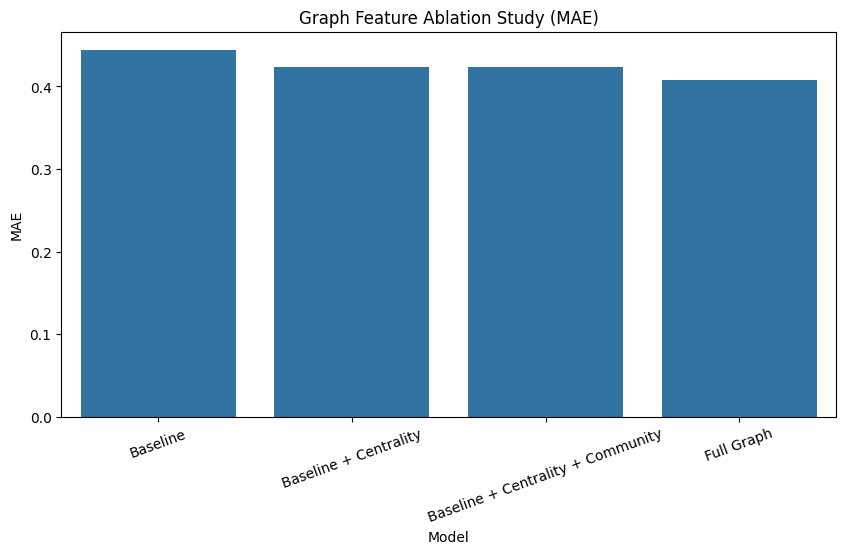

In [72]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=ablation_df,
    x="Model",
    y="MAE"
)

plt.xticks(rotation=20)

plt.title(
    "Graph Feature Ablation Study (MAE)"
)

plt.show()

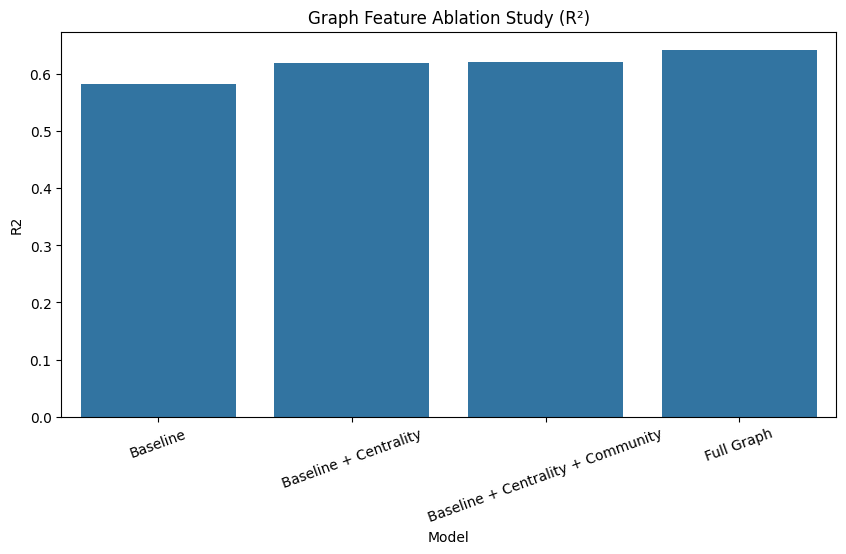

In [73]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=ablation_df,
    x="Model",
    y="R2"
)

plt.xticks(rotation=20)

plt.title(
    "Graph Feature Ablation Study (R²)"
)

plt.show()

In [74]:
best_row = ablation_df.sort_values(
    "MAE"
).iloc[0]

print("="*60)

print(
    f"Best Model: {best_row['Model']}"
)

print(
    f"MAE: {best_row['MAE']:.4f}"
)

print(
    f"RMSE: {best_row['RMSE']:.4f}"
)

print(
    f"R²: {best_row['R2']:.4f}"
)

print("="*60)

Best Model: Full Graph
MAE: 0.4076
RMSE: 0.9300
R²: 0.6421


REASEARCH CONCLUSION : Approximately half of the graph-derived predictive gain originates from classical centrality measures, while the remaining gain originates from Node2Vec latent graph representations. Community assignments contributed negligible standalone predictive value.

Now we also include edge feats

In [75]:
edge_features = pd.read_csv(
    f"{BASE_PATH}/data/graph_data/graph_edge_features.csv"
)

edge_features.head()

,source,destination,same_community,pagerank_difference,betweenness_difference,hub_score_difference,authority_score_difference,embedding_cosine_similarity
0,IND000000AAL,IND411033AAA,1,0.005793,0.043254,0.015186,0.017323,0.984221
1,IND411033AAA,IND000000AAL,1,0.005793,0.043254,0.015186,0.017323,0.984221
2,IND411033AAA,IND000000ACB,0,0.005250,0.176974,0.027710,0.015198,0.438848
3,IND411033AAA,IND400072AAB,0,0.004390,0.038157,0.009825,0.012034,0.758759
4,IND411033AAA,IND403726AAA,0,0.004842,0.035456,0.015025,0.016595,0.808320


In [76]:
print(edge_features.columns.tolist())
print(edge_features.shape)

['source', 'destination', 'same_community', 'pagerank_difference', 'betweenness_difference', 'hub_score_difference', 'authority_score_difference', 'embedding_cosine_similarity']
(2783, 8)


In [77]:
edge_features = pd.read_csv(
    f"{BASE_PATH}/data/graph_data/graph_edge_features.csv"
)

print(edge_features.shape)
edge_features.head()

(2783, 8)


,source,destination,same_community,pagerank_difference,betweenness_difference,hub_score_difference,authority_score_difference,embedding_cosine_similarity
0,IND000000AAL,IND411033AAA,1,0.005793,0.043254,0.015186,0.017323,0.984221
1,IND411033AAA,IND000000AAL,1,0.005793,0.043254,0.015186,0.017323,0.984221
2,IND411033AAA,IND000000ACB,0,0.005250,0.176974,0.027710,0.015198,0.438848
3,IND411033AAA,IND400072AAB,0,0.004390,0.038157,0.009825,0.012034,0.758759
4,IND411033AAA,IND403726AAA,0,0.004842,0.035456,0.015025,0.016595,0.808320


In [78]:
edge_features = edge_features.rename(
    columns={
        "source": "source_center",
        "destination": "destination_center"
    }
)

In [79]:
df_edge = df.merge(
    edge_features,
    on=[
        "source_center",
        "destination_center"
    ],
    how="left"
)
print(df_edge.shape)

In [87]:
edge_cols = [

    "same_community",
    "pagerank_difference",
    "betweenness_difference",
    "hub_score_difference",
    "authority_score_difference",
    "embedding_cosine_similarity"
]

print(df_edge[edge_cols].head())

   same_community  pagerank_difference  betweenness_difference  \
0               1             0.000037                0.000002   
1               1             0.000037                0.000002   
2               1             0.000037                0.000002   
3               1             0.000037                0.000002   
4               1             0.000037                0.000002   

   hub_score_difference  authority_score_difference  \
0              0.000084                    0.000073   
1              0.000084                    0.000073   
2              0.000084                    0.000073   
3              0.000084                    0.000073   
4              0.000084                    0.000073   

   embedding_cosine_similarity  
0                     0.987639  
1                     0.987639  
2                     0.987639  
3                     0.987639  
4                     0.987639  


In [88]:
train_edge = df_edge.iloc[train_idx].copy()

test_edge = df_edge.iloc[test_idx].copy()

In [89]:
edge_graph_features = (

    baseline_features
    + centrality_features
    + community_features
    + embedding_features
    + edge_cols
)

In [90]:
missing = [

    c
    for c in edge_graph_features
    if c not in train_edge.columns

]

print(missing)

[]


In [91]:
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [92]:
cat_cols = [

    "route_type",

    "src_community_id",
    "dst_community_id"
]

num_cols = [

    c
    for c in edge_graph_features
    if c not in cat_cols
]

In [93]:
edge_prep = ColumnTransformer([

    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        cat_cols
    ),

    (
        "num",
        SimpleImputer(
            strategy="median"
        ),
        num_cols
    )
])

In [94]:
edge_model = Pipeline([

    ("prep", edge_prep),

    (
        "lgbm",
        LGBMRegressor(
            n_estimators=1000,
            learning_rate=0.03,
            num_leaves=31,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [95]:
edge_model.fit(
    train_edge[edge_graph_features],
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.139077 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 22269
[LightGBM] [Info] Number of data points in the train set: 116451, number of used features: 244
[LightGBM] [Info] Start training from score 2.124701


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['route_type',
                                                   'src_community_id',
                                                   'dst_community_id']),
                                                 ('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['osrm_time', 'osrm_distance',
                                                   'osrm_speed', 'trip_hour',
                                                   'trip_weekday', 'trip_month',
                                                   'is_weekend',
                                                   'trip_to_scan_minutes',
                                                   'trip_to_cutoff_minutes',
                                                   'source_vol...
                                                   'dst_degree_centrality',
                                                   'dst_in_degree_centrality',
                                                   'dst_out_degree_centrality',
                                                   'dst_betweenness_centrality',
                                                   'dst_closeness_centrality',
                                                   'dst_pagerank',
                                                   'dst_hub_score',
                                                   'dst_authority_score',
                                                   'src_community_size',
                                                   'dst_community_size', ...])])),
                ('lgbm',
                 LGBMRegressor(colsample_bytree=0.8, learning_rate=0.03,
                               n_estimators=1000, n_jobs=-1, random_state=42,
                               subsample=0.8))])

In [96]:
edge_pred = edge_model.predict(
    test_edge[edge_graph_features]
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [97]:
edge_metrics = evaluate(
    y_test,
    edge_pred
)

edge_metrics

{'MAE': 0.40563727077378936,
 'RMSE': np.float64(0.9365621247401877),
 'R2': 0.6369884361696732,
 'MAPE': np.float64(18.67229710107841)}

In [98]:
full_graph_mae = 0.407613
full_graph_rmse = 0.930006

In [99]:
print("Full Graph MAE :", 0.407613)
print("Edge Graph MAE :", edge_metrics["MAE"])

gain = (
    0.407613
    - edge_metrics["MAE"]
) / 0.407613 * 100

print(f"Edge Gain: {gain:.2f}%")

Full Graph MAE : 0.407613
Edge Graph MAE : 0.40563727077378936
Edge Gain: 0.48%


In [100]:
edge_metrics
gain

0.48470711832317487